In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def CalculateTFIDF(x):

    tfidf=TfidfVectorizer() #计算x的TF-IDF矩阵
    weight=tfidf.fit_transform(x).toarray()
    word=tfidf.get_feature_names_out() #得到不重复的关键词

    print(word)
    #weight文档数目
    print("大小是 ",len(word)," ",len(weight))
    #计算每个词的最大TF-IDF权重
    maxweight=np.max(weight,axis=0) #这是一维数组

    #计算每个词的最大TF-IDF权重
    word_fre={word[j]: maxweight[j] for j in range(len(word))}

    #按权重排序（降序）
    sorted_word_fre=sorted(word_fre.items(),key=lambda kv: (-kv[1],kv[0]))
    print(sorted_word_fre)
    return word_fre

In [20]:
#excel新添一列的词频分析
import pandas as pd
import re
import jieba

def getStopwordsList():
    stopwords=[line.strip() for line in open(r'E:\【论文】\heritage science\0602analysis\stopwords-zh.txt',encoding='UTF-8').readlines()]
    return stopwords

def match_chinese(text):
    #匹配所有汉字字符(只寻找中文)
    chinese_pattern=r'[\u4e00-\u9fa5]+' #\u4e00-\u9fa5用于表示Unicode中常见的汉字范围

    #查找所有汉字
    chinese_text=re.findall(chinese_pattern,text)
    return chinese_text
#list->string
def processWords(sentence):
    sentence_list=match_chinese(sentence)
    sentence=''
    for sentence_l in sentence_list:
        sentence += sentence_l
    return sentence

#对句子进行中文分词
def segDepart(sentence):
    #对文档中的每一行进行中文分词
    sentence_depart=jieba.lcut(str(sentence).strip())
    return sentence_depart

#去除停用词
def moveStopwords(sentence_list,stop_list):
    #去停用词
    out_list=[]
    for word in sentence_list:
        if word not in stop_list:
            out_list.append(word)
    return out_list

def ProcessData(filepath):
    """
    :param filepath: Excel文件路径
    :return: 分词后的文本列表
    """
    data = pd.read_excel(filepath)
    stop_list = getStopwordsList()

    # 新建一列存放分词后的结果
    data['segmented_text'] = ''    

    for i in range(len(data)):
        str_row = data.iloc[i, 4]  # 处理H列
        
        # 避免空值出错
        if pd.isna(str_row):
            continue
        
        # 移除不合适的字符
        str_row = processWords(str_row)
        # 分词
        str_row = segDepart(str_row)
        # 移除停用词
        line_without = moveStopwords(str_row, stop_list)
        # 拼接成一句话
        lineStr = ' '.join(line_without)
        # 更新Excel中的新列
        data.at[i, 'segmented_text'] = lineStr

    # 将修改后的DataFrame保存回原Excel文件
    data.to_excel(filepath, index=False)

# 使用示例
ProcessData(r"E:\【论文】\heritage science\0602analysis\people's commune.xlsx")  # 替换为你的文件路径

In [21]:
import pandas as pd

def ProcessData(filepath):
    # 读取Excel文件
    data = pd.read_excel(filepath)
    
    # 将所有行的 segmented_text 列拼接成一段话，并用 '' 引号包裹，每个词之间用逗号分隔
    all_text = ', '.join([f"'{text}'" for text in data['segmented_text'].dropna()])  # 用逗号分隔并加引号
    
    return all_text

# 使用示例
all_text = ProcessData(r"E:\【论文】\heritage science\0602analysis\people's commune.xlsx")  # 替换为你的文件路径

# 输出拼接后的文本
print(all_text)

'肥料', '养猪 蔬菜 养鱼 养禽', '收音机 加工厂', '安培', '伞', '蔬菜 白菜 萝卜 黄瓜', '发电机 台', '米 水利 开发', '米 水利 开发', '渔业 大麦 米', '竹林 竹', '米', '杉', '小麦', '米 虫害', '米', '米 小麦 大麦', '生产 工厂', '米', '米', '水稻 种植 米', '社员 土地 小麦 种植 米 小麦', '季节性 中稻 种植 米', '副业 手艺 品 养猪', '麦子 油菜籽 豌豆 使用 河泥', '米', '元山 米 地势 高 水源 经常 干旱', '清修 小麦 种植 油菜籽 小麦 油菜籽', '大麻 花生 烟草 米 蔬菜 林业 养蚕 药材', '米 麦 家畜 养鱼', '生产 小队 年水 田亩 小麦 大麦 种植 米 小麦 养猪 渔业 螟 危害 水乡 湿地', '米 螟害', '猪羊', '圩塘 生产队 米', '米 螟害', '生产队 米麦 大豆 玉米', '生产 小队 农具 工厂 年冬年 中小 农机具 件 米 油料作物', '米', '修配 站', '小麦', '冬期 副业 狩猎 野生 竹材 编织 木炭 养畜 养禽 果树 山区', '食堂 食堂 耕地 蔬菜 萝卜 百合 调味料 作物', '生产 院麦 绿肥', '耕地 约 排灌 机械 台 马力 米 灌溉 排水 设备 完备', '土 化肥 工厂 麦米 养猪', '麦类 种植 大豆 芝麻 土 化肥 工厂 麦类 米 土化 肥料 日产 斤 高产 富裕', '麦类 种植 麦米 养猪', '蔬菜 麦 长江 小岛 高产', '麦', '种植 蔬菜 麦 长江 沿岸地区 低产', '连根 菱角 鱼猪 蔬菜 米 副业 元 每年 元', '麦', '幼儿园 邮电 学校 电话 邮员 文艺 学校 业余 红 专业 大学 小学 普通中学 半耕半读 农业大学 大学 业余 中学 专业 学校', '麦', '麦类 重昌石 萤石', '米 番薯 丘陵地区', '米', '植树 木槿 柳梨桃 茶 杨槐', '贮水池 食堂 米 养猪', '大理石', '竹木 农机具 修配 站 米', '米', '米 捕鱼 林业', '钢铁 公斤', '湿地 麦 番薯 绵油 玉米 保有 水利建设 资金', '小麦 大麦 前 大麦 米', '油菜籽 种植 油菜籽', '秋作 米 玉米

In [22]:
x=['肥料', '养猪 蔬菜 养鱼 养禽', '收音机 加工厂', '安培', '伞', '蔬菜 白菜 萝卜 黄瓜', '发电机 台', '米 水利 开发', '米 水利 开发', '渔业 大麦 米', '竹林 竹', '米', '杉', '小麦', '米 虫害', '米', '米 小麦 大麦', '生产 工厂', '米', '米', '水稻 种植 米', '社员 土地 小麦 种植 米 小麦', '季节性 中稻 种植 米', '副业 手艺 品 养猪', '麦子 油菜籽 豌豆 使用 河泥', '米', '元山 米 地势 高 水源 经常 干旱', '清修 小麦 种植 油菜籽 小麦 油菜籽', '大麻 花生 烟草 米 蔬菜 林业 养蚕 药材', '米 麦 家畜 养鱼', '生产 小队 年水 田亩 小麦 大麦 种植 米 小麦 养猪 渔业 螟 危害 水乡 湿地', '米 螟害', '猪羊', '圩塘 生产队 米', '米 螟害', '生产队 米麦 大豆 玉米', '生产 小队 农具 工厂 年冬年 中小 农机具 件 米 油料作物', '米', '修配 站', '小麦', '冬期 副业 狩猎 野生 竹材 编织 木炭 养畜 养禽 果树 山区', '食堂 食堂 耕地 蔬菜 萝卜 百合 调味料 作物', '生产 院麦 绿肥', '耕地 约 排灌 机械 台 马力 米 灌溉 排水 设备 完备', '土 化肥 工厂 麦米 养猪', '麦类 种植 大豆 芝麻 土 化肥 工厂 麦类 米 土化 肥料 日产 斤 高产 富裕', '麦类 种植 麦米 养猪', '蔬菜 麦 长江 小岛 高产', '麦', '种植 蔬菜 麦 长江 沿岸地区 低产', '连根 菱角 鱼猪 蔬菜 米 副业 元 每年 元', '麦', '幼儿园 邮电 学校 电话 邮员 文艺 学校 业余 红 专业 大学 小学 普通中学 半耕半读 农业大学 大学 业余 中学 专业 学校', '麦', '麦类 重昌石 萤石', '米 番薯 丘陵地区', '米', '植树 木槿 柳梨桃 茶 杨槐', '贮水池 食堂 米 养猪', '大理石', '竹木 农机具 修配 站 米', '米', '米 捕鱼 林业', '钢铁 公斤', '湿地 麦 番薯 绵油 玉米 保有 水利建设 资金', '小麦 大麦 前 大麦 米', '油菜籽 种植 油菜籽', '秋作 米 玉米 粟 人参 花生 烟草 高粱 荞麦 马铃薯 蔬菜 绿肥', '米', '耕地', '早熟 麦 种植 麦', '蔬菜 洋葱 大蒜 辣椒 石楠 绿肥', '麦', '米 玉米 粟', '社员 番薯 芋头 种植 人参 番薯 芋头 人参 高粱 小米 玉米 蔬菜', '农具 整备 活动', '养猪', '社员 户麦亩 米 電力 灌溉 麦米 养猪', '麦', '蔬菜 豆类', '油菜籽 养蜂', '米绵', '牧畜 蔬菜', '米', '农具 修理 小麦 大麦', '深耕 野战 团年 耕地 麦', '社员 余人米 蔬菜 食用', '鱼塘 扩大 米 养鱼 小麦 大麦 水生植物 连根 菱形 虫', '连根', '养畜', '绳索 索引 式 农耕', '农具 工厂 麦 家畜 副业 狩猎', '米绵 番薯', '米 蔬菜', '麦', '白马 夏季 副业 药材 野猪 狩鱼 木碳 烧', '少年班 农民 读报', '米', '湿地 里 种植 芦苇', '渔业', '自然 灌溉 米 蔬菜 绿地', '生产队 农地 水稻 米', '手工业 农机具 杂谷 原料 材料 铁木 竹柳 管理 强化', '牛 大豆', '全社 户 春季 作物 种植 戚庄 玉米 种植 大豆 玉米', '刘场 养猪场 栋 新 建筑 番薯 高粱 大麦 小麦 玉米 猪 刘场 头', '麦 玉米', '麦亩 麦 沂河 下游', '玉米', '小麦', '社员 土地 碱性 粮食作物', '第六 队员 小麦 种植 麦', '土地 肥 工厂 玉米 大豆 番薯 高粱 绵 小麦 大麦 米', '玉米 大豆', '耕地 玉米 麦 大豆 绵 番薯', '龙 苴 生产队 队员 户绵', '黄麻 种植 黄麻 斤', '麻', '米绵', '约 鸭子 河泥 施肥', '米 蔬菜 玉米 养猪 编织物', '畜牧 猪 牛米 大豆', '麦猪', '米', '春 余亩 蔬菜 大豆 水果 莲连根 油菜籽', '蔡工 花生 玉米 米', '米 萝卜 牛草 番薯 干菜', '杂谷 精油 制粉 大豆 全公社 元 平原 杂 谷地 水面 碱性 土壤', '联合 改良 碱性 土壤 米 养鱼 水利 条件 优越 米 淡水鱼', '工厂 工业 种 棉花 小麦 杂谷 番薯 大豆 工业生产 元年 棉花 杂 谷地 带', '大麦 小麦', '玉米 高粱 番薯 果树 花生 油料作物', '番薯 种植 番薯', '番薯', '棉花 仓库 棉花', '棉花 拖拉机 棉花', '户 分散 村庄 居住 托儿所 幸福 院 缝纫机 工厂 耕地 养猪 玉米 麻 居住 条件 差异', '番薯', '绿地 养猪 野草 番薯 玉米 饲料作物', '麦 养猪 羊', '杂谷 种植 杂谷 番薯 小麦 玉米 烟草', '竹材 木材 槐 农机具 修理 能够 自给自足', '淡水 渔业 洪泽湖 畔', '小麦 小麦', '米 虫害', '厕所', '大麻 斤', '业余 学校 幼儿园', '大麦 烟草 玉米 红薯', '麦', '绵麦 畜牧 牛', '农具 水泥 工厂 蓄水池 个绵 红薯 油桐', '麦 主要 小麦', '米', '养猪', '小麦', '红旗 哲学 研究所', '麦', '麦', '麦', '秋天 麦类 麦 红薯 绿豆 大豆 菜种', '知识青年 南瓜 红薯', '麦', '豆类', '豆亩 豆', '红薯 米 落花生 大豆 粟', '蔬菜', '童营 米绵 副业 编织物', '绵 农机具 修配 站个 米 绵', '小麦', '农具 工厂', '民兵组织 发达', '农具 制配 工厂 高粱 植树 杨树 碱性 土壤', '米绵', '秋 人参', '大麦 小麦 河泥 斤', '棉花 绵', '社员 户 社员 利用 麦秸 产品 材料 帽子 包等 位置 贩卖 万 麦秸 产品 元', '羊 蔬菜', '铁木 竹瓦 铜匠 组成 手工业 技术 学习班 副业 竹器 等绵', '杂粮 前年 增产 绵年 前年 增产 玉米 社员 前年', '油桐', '船民 户年 养猪 头', '养猪', '米', '米', '粮食作物', '菜种 菜种 米 养猪', '米麦', '绵 大麦 小麦 绵 自古 棉花', '名 各类 技术人员', '中小 农机具 件 大麦 绿肥 人参 玉米 绵三墩 绿肥 元', '米 水乡 生产 条件 良好', '粮食作物 麦', '养猪', '养牛', '农具 工厂 粮食作物 水利建设', '米藤芋 养猪', '米绵 蔬菜', '豆猪 第八 大豆 生产量 斤', '小麦', '玉米', '植树', '药材 薄荷 黄麻 玉米 药用 菊 除虫菊 薄荷 薄荷 生产量 全国 总 生产量 特殊 经济作物', '海边', '粮食作物 养猪', '绵', '小麦', '坟场', '储藏 粪便 余所 麦', '蔬菜 茄子 白菜 胡萝卜 红薯', '工厂 绵年 生产 斤', '绵', '绵 绵', '绵绵 集中', '麦', '绵 绵', '绵', '米', '米', '菜种 江湖', '桑 田亩 总 养蚕 春蚕 元 元 米麦', '农具 工场 米', '玻璃仪器 工厂 从业人员 工业生产 种 工业制品 工业 日产 元', '蓉麓 大队 耕地 桑 田亩 总 养蚕 农副业 畜牧', '蔬菜', '米', '桑园 全 养蚕 养蚕', '小麦 米', '米 小麦', '生产队 米', '米', '化肥 工场', '麦', '菜种', '绵米', '绵年 期间 采用 河泥 施肥', '二季 作 水稻 米 养鱼 菱角', '米', '水生植物 绿肥', '米 使用 河泥', '生产队 米', '家畜 羊麦', '米 小麦 菜种 豆类 绿肥', '米', '米麦', '雪 泾 社员 小麦 米 果物 野菜 类 西瓜 茄子 番薯', '青年人 机械 工厂 米 养禽 鹅 鸟 养蚕', '米麦 菜种', '小麦 米 绵 养畜 耕牛', '小麦', '水稻 米 斤', '冬季 副业生产 钱 买 多艘 农船 化学肥料', '米', '米', '米', '梅 鲚 鱼 大湖 银鱼 全国 有名', '新 曙 生产队 竹材 每户 株 木材 每户 株柳槐 榉 榆', '米', '高产 湿地 耕地 小麦 畜牧', '士农 技术学校 麦', '麦', '米', '米', '绵 大豆 菜种 棉花 高产', '学习 技术', '养猪', '米麦 蔬菜', '小麦 大麦 杀虫剂 使用 药水 石灰 硫磺 合剂', '养蚕', '小麦 麦 菜种 蔬菜', '人米 杂粮 瓜 野菜 隙地 田 利用 高 生产', '社员 公社 食堂 米 野菜 米 生产 情况 供 出 种子 饲料 全社 每人 粮食 斤够 十个月 吃', '小麦 米', '麦', '个桑 田亩 业余 文化 技术学校 养蚕 养猪 绿肥 蔬菜 小麦 水利 开发', '米', '小麦 小麦 收获量 菜种 蚕豆', '农具 工厂 鸭子 鹅 鸟', '麦米 萝卜 菜种', '绿肥 施肥 麦米 养猪 养兔 施肥量 长江 南岸', '米', '米 员工 人均收入', '名茶 碧螺春']

In [23]:
word_fre=CalculateTFIDF(x)

['下游' '专业' '丘陵地区' '业余' '个桑' '个绵' '中学' '中小' '中稻' '主要' '二季' '产品' '人参' '人均收入'
 '人米' '从业人员' '仓库' '优越' '位置' '低产' '余亩' '余人米' '余所' '作物' '使用' '保有' '修理' '修配'
 '储藏' '元山' '元年' '全公社' '全国' '全社' '公斤' '公社' '养兔' '养牛' '养猪' '养猪场' '养畜' '养禽'
 '养蚕' '养蜂' '养鱼' '农业大学' '农具' '农副业' '农地' '农机具' '农民' '农耕' '农船' '冬季' '冬期' '分散'
 '刘场' '利用' '制粉' '制配' '前年' '副业' '副业生产' '加工厂' '包等' '化学肥料' '化肥' '十个月' '半耕半读'
 '南岸' '南瓜' '危害' '厕所' '原料' '发电机' '发达' '各类' '合剂' '名茶' '员工' '哲学' '团年' '土化'
 '土地' '土壤' '圩塘' '地势' '坟场' '增产' '士农' '夏季' '多艘' '大学' '大湖' '大理石' '大蒜' '大豆'
 '大队' '大麦' '大麻' '季节性' '学习' '学习班' '学校' '安培' '完备' '家畜' '富裕' '小学' '小岛' '小米'
 '小队' '小麦' '少年班' '居住' '山区' '工业' '工业制品' '工业生产' '工厂' '工场' '差异' '帽子' '干旱'
 '干菜' '平原' '年冬年' '年水' '幸福' '幼儿园' '建筑' '开发' '强化' '情况' '戚庄' '户年' '户绵' '户麦亩'
 '手工业' '手艺' '托儿所' '扩大' '技术' '技术人员' '技术学校' '拖拉机' '捕鱼' '排水' '排灌' '收获量' '收音机'
 '改良' '整备' '文化' '文艺' '斤够' '施肥' '施肥量' '日产' '早熟' '春季' '春蚕' '普通中学' '有名' '期间'
 '木材' '木槿' '木炭' '木碳' '机械' '杀虫剂' '杂粮' '杂谷' '材料' '村庄' '条件' '杨树' '杨槐' '林业'
 '果树' '果物' '柳梨桃' '株柳槐' '桑园' '棉花' '植树' '每人' '每年

In [24]:
import matplotlib.font_manager as fm
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'simhei' in font.lower():
        print(font)

C:\Windows\Fonts\simhei.ttf
C:\WINDOWS\Fonts\simhei.ttf


In [25]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt  # 添加这行导入语句
def drawWordCloud(wordsDict, name):
    
    wordcloud = WordCloud(
        font_path="simhei.ttf",  # 设置字体路径，支持中文
        width=3000, height=2400,  # 设置图片大小
        background_color="white",  # 背景颜色
        max_words=300,  # 增加最大显示词数
        max_font_size=300,  # 最大字体大小，防止最大词的字体过大
        relative_scaling=0.5,  # 控制词频占比，设置为较小的值可以减小最大词频的字体
        random_state=30,  # 随机生成的词云状态
        colormap="Set2",  # 设置颜色方案，可以选择其他的colormap，如 'plasma', 'inferno', etc.
        #contour_color='black',  # 给词云添加轮廓线
        #contour_width=1,  # 设置轮廓线的宽度
    ).generate_from_frequencies(wordsDict)

    # 显示图片（可选）
    plt.figure(figsize=(12, 9))     # 控制显示窗口大小
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.tight_layout()

    # 保存为高分辨率（300 dpi）图像
    output_path = f'{name}_词云_300dpi.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    # 显示确认信息
    print(f"词云图已保存为：{output_path}")


词云图已保存为：江苏人民公社0609_词云_300dpi.png


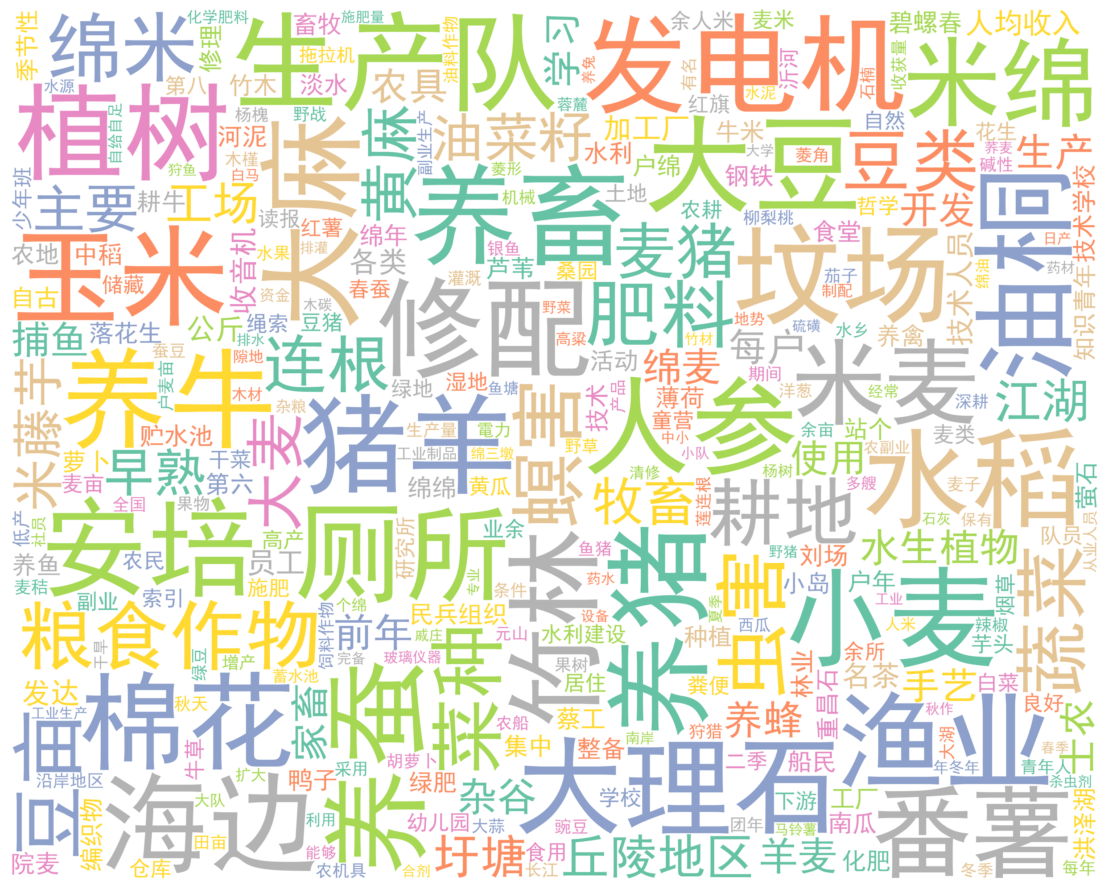

In [26]:
# 调用函数生成词云
drawWordCloud(word_fre, '江苏人民公社0609')